In [24]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from pathlib import Path # manage paths for the project

In [2]:
# define the path of the data
data_path = Path('..') / 'data' / 'raw' / 'educacionCol.csv'

In [18]:
# Cargar dataset

df = pd.read_csv(data_path, low_memory=False)
df.head()

,Código de la Institución,IES PADRE,Institución de Educación Superior (IES),Principal oSeccional,Id_Sector,Id_Caracter,Código del departamento(IES),Departamento de domicilio de la IES,Código del Municipio(IES),Municipio dedomicilio de la IES,...,Id_Nucleo,Núcleo Básico del Conocimiento (NBC),Código del Departamento(Programa),Departamento de oferta del programa,Código del Municipio(Programa),Municipio de oferta del programa,Id Género,Año,Semestre,Total Matriculados
0,2833,2833,CORPORACION UNIVERSITARIA REMINGTON,PRINCIPAL,2,3,5,ANTIOQUIA,5001,MEDELLIN,...,612,CONTADURIA PUBLICA,23,CORDOBA,23670,SAN ANDRES DE SOTAVENTO,2,2015,1,2
1,2833,2833,CORPORACION UNIVERSITARIA REMINGTON,PRINCIPAL,2,3,5,ANTIOQUIA,5001,MEDELLIN,...,612,CONTADURIA PUBLICA,23,CORDOBA,23670,SAN ANDRES DE SOTAVENTO,1,2015,1,2
2,2833,2833,CORPORACION UNIVERSITARIA REMINGTON,PRINCIPAL,2,3,5,ANTIOQUIA,5001,MEDELLIN,...,612,CONTADURIA PUBLICA,23,CORDOBA,23672,SAN ANTERO,2,2015,1,9
3,2833,2833,CORPORACION UNIVERSITARIA REMINGTON,PRINCIPAL,2,3,5,ANTIOQUIA,5001,MEDELLIN,...,612,CONTADURIA PUBLICA,23,CORDOBA,23672,SAN ANTERO,1,2015,1,1
4,2833,2833,CORPORACION UNIVERSITARIA REMINGTON,PRINCIPAL,2,3,5,ANTIOQUIA,5001,MEDELLIN,...,612,CONTADURIA PUBLICA,23,CORDOBA,23675,SAN BERNARDO DEL VIENTO,2,2015,1,18


In [4]:
df.tail()

,Código de la Institución,IES PADRE,Institución de Educación Superior (IES),Principal oSeccional,Id_Sector,Id_Caracter,Código del departamento(IES),Departamento de domicilio de la IES,Código del Municipio(IES),Municipio dedomicilio de la IES,...,Id_Nucleo,Núcleo Básico del Conocimiento (NBC),Código del Departamento(Programa),Departamento de oferta del programa,Código del Municipio(Programa),Municipio de oferta del programa,Id Género,Año,Semestre,Total Matriculados
390898,9935,9935,UNIDAD TECNOLÓGICA DEL MAGDALENA MEDIO - UTEM -,Principal,2,2,68,Santander,68081,Barrancabermeja,...,0,Sin clasificar,68,Santander,68081,Barrancabermeja,2,2021,1,21
390899,9936,9936,CORPORACIÓN UNIVERSITARIA AUTÓNOMA DEL NORTE,Principal,2,3,54,Norte De Santander,54001,San José De Cúcuta,...,611,Economía,54,Norte De Santander,54001,San José De Cúcuta,1,2021,1,1
390900,9936,9936,CORPORACIÓN UNIVERSITARIA AUTÓNOMA DEL NORTE,Principal,2,3,54,Norte De Santander,54001,San José De Cúcuta,...,611,Economía,54,Norte De Santander,54001,San José De Cúcuta,2,2021,1,6
390901,9936,9936,CORPORACIÓN UNIVERSITARIA AUTÓNOMA DEL NORTE,Principal,2,3,54,Norte De Santander,54001,San José De Cúcuta,...,0,Sin clasificar,54,Norte De Santander,54001,San José De Cúcuta,1,2021,1,1
390902,9936,9936,CORPORACIÓN UNIVERSITARIA AUTÓNOMA DEL NORTE,Principal,2,3,54,Norte De Santander,54001,San José De Cúcuta,...,0,Sin clasificar,54,Norte De Santander,54001,San José De Cúcuta,2,2021,1,8


In [5]:
# exploracion inicial
print(f"Dimensiones del dataset: {df.shape[0]} filas y {df.shape[1]} columnas \n")
df.info()

Dimensiones del dataset: 390903 filas y 26 columnas 

<class 'pandas.DataFrame'>
RangeIndex: 390903 entries, 0 to 390902
Data columns (total 26 columns):
 #   Column                                   Non-Null Count   Dtype
---  ------                                   --------------   -----
 0   Código de la Institución                 390903 non-null  int64
 1   IES PADRE                                390903 non-null  int64
 2   Institución de Educación Superior (IES)  390903 non-null  str  
 3   Principal oSeccional                     390903 non-null  str  
 4   Id_Sector                                390903 non-null  int64
 5   Id_Caracter                              390903 non-null  int64
 6   Código del departamento(IES)             390903 non-null  int64
 7   Departamento de domicilio de la IES      390903 non-null  str  
 8   Código del Municipio(IES)                390903 non-null  int64
 9   Municipio dedomicilio de la IES          390903 non-null  str  
 10  Código SNIES 

In [6]:
# Analisis de valores nulos

nulos = df.isnull().sum()
nulos_porcentaje = (nulos / len(df)) * 100
df_nulos = pd.DataFrame({'Nulos': nulos, 'Porcentaje (%)': nulos_porcentaje})
print(df_nulos)

# Mostrar solo las columnas que tienen nulos
display(df_nulos[df_nulos['Nulos'] > 0].sort_values(by='Porcentaje (%)', ascending=False))

# No tenemos nulos

                                         Nulos  Porcentaje (%)
Código de la Institución                     0             0.0
IES PADRE                                    0             0.0
Institución de Educación Superior (IES)      0             0.0
Principal oSeccional                         0             0.0
Id_Sector                                    0             0.0
Id_Caracter                                  0             0.0
Código del departamento(IES)                 0             0.0
Departamento de domicilio de la IES          0             0.0
Código del Municipio(IES)                    0             0.0
Municipio dedomicilio de la IES              0             0.0
Código SNIES delprograma                     0             0.0
Programa Académico                           0             0.0
Id_Nivel                                     0             0.0
Id_Nivel_Formacion                           0             0.0
Id_Metodologia                               0         

,Nulos,Porcentaje (%)


In [7]:
total_duplicados = df.duplicated().sum()
print(f"Se encontraron {total_duplicados} filas exactamente duplicadas en el dataset.")

if total_duplicados > 0:
    # Mostrar una muestra de los duplicados
    display(df[df.duplicated(keep=False)].sort_values(by='Código SNIES delprograma').head(4))

Se encontraron 106599 filas exactamente duplicadas en el dataset.


,Código de la Institución,IES PADRE,Institución de Educación Superior (IES),Principal oSeccional,Id_Sector,Id_Caracter,Código del departamento(IES),Departamento de domicilio de la IES,Código del Municipio(IES),Municipio dedomicilio de la IES,...,Id_Nucleo,Núcleo Básico del Conocimiento (NBC),Código del Departamento(Programa),Departamento de oferta del programa,Código del Municipio(Programa),Municipio de oferta del programa,Id Género,Año,Semestre,Total Matriculados
195533,1101,1101,UNIVERSIDAD NACIONAL DE COLOMBIA,PRINCIPAL,1,4,11,BOGOTA D.C.,11001,BOGOTA D.C.,...,824,INGENIERIA AGRONOMICA PECUARIA Y AFINES,11,BOGOTA D.C.,11001,BOGOTA D.C.,2,2015,1,199
195534,1101,1101,UNIVERSIDAD NACIONAL DE COLOMBIA,PRINCIPAL,1,4,11,BOGOTA D.C.,11001,BOGOTA D.C.,...,824,INGENIERIA AGRONOMICA PECUARIA Y AFINES,11,BOGOTA D.C.,11001,BOGOTA D.C.,1,2015,1,438
8,1101,1101,UNIVERSIDAD NACIONAL DE COLOMBIA,PRINCIPAL,1,4,11,BOGOTA D.C.,11001,BOGOTA D.C.,...,824,INGENIERIA AGRONOMICA PECUARIA Y AFINES,11,BOGOTA D.C.,11001,BOGOTA D.C.,1,2015,1,438
6,1101,1101,UNIVERSIDAD NACIONAL DE COLOMBIA,PRINCIPAL,1,4,11,BOGOTA D.C.,11001,BOGOTA D.C.,...,824,INGENIERIA AGRONOMICA PECUARIA Y AFINES,11,BOGOTA D.C.,11001,BOGOTA D.C.,2,2015,1,199


In [8]:
# Validacion de tipos de datos
display(df.dtypes)

# Total de matriculados esta como texto hay que corregirlo

Código de la Institución                   int64
IES PADRE                                  int64
Institución de Educación Superior (IES)      str
Principal oSeccional                         str
Id_Sector                                  int64
Id_Caracter                                int64
Código del departamento(IES)               int64
Departamento de domicilio de la IES          str
Código del Municipio(IES)                  int64
Municipio dedomicilio de la IES              str
Código SNIES delprograma                   int64
Programa Académico                           str
Id_Nivel                                   int64
Id_Nivel_Formacion                         int64
Id_Metodologia                             int64
Id_Area                                      str
Id_Nucleo                                    str
Núcleo Básico del Conocimiento (NBC)         str
Código del Departamento(Programa)          int64
Departamento de oferta del programa          str
Código del Municipio

Total de Outliers: 48142


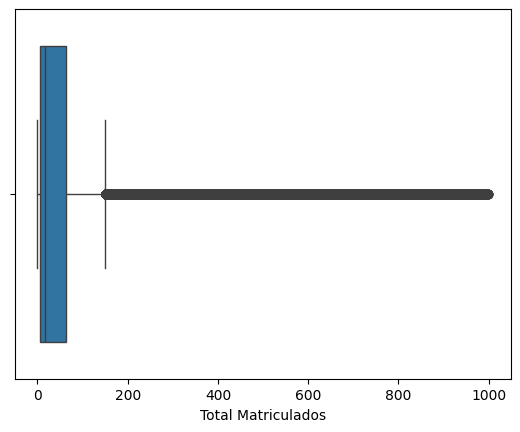

In [12]:
# 2. Forzar conversión a numérico, rellenar nulos con 0 y pasar a entero
df['Total Matriculados'] = pd.to_numeric(df['Total Matriculados'], errors='coerce').fillna(0).astype('int')

# --- Gráfico de Outliers ---
sns.boxplot(x=df['Total Matriculados'])

# --- Cuantificación de Outliers (Método IQR) ---
Q1 = df['Total Matriculados'].quantile(0.25)
Q3 = df['Total Matriculados'].quantile(0.75)
IQR = Q3 - Q1
limite_superior = Q3 + 1.5 * IQR
outliers = df[df['Total Matriculados'] > limite_superior]
print(f"Total de Outliers: {len(outliers)}")

In [14]:
# Revisar si hay municipios escritos de diferentes formas (Mayúsculas vs Minúsculas o espacios al final)
municipios_unicos = df['Municipio de oferta del programa'].dropna().unique()
print(f"Total municipios únicos (sin limpiar): {len(municipios_unicos)}")

# Aplicando strip y upper para ver si el número se reduce (lo que indicaría inconsistencias de formato)
municipios_limpios = df['Municipio de oferta del programa'].dropna().astype(str).str.strip().str.upper().unique()
print(f"Total municipios únicos (limpiando espacios y mayúsculas): {len(municipios_limpios)}")

# Verificar longitudes raras en los años (deberían ser 4 caracteres)
años_inconsistentes = df[df['Año'].astype(str).str.len() != 4]['Año'].unique()
if len(años_inconsistentes) > 0:
    print(f"Años con formato inconsistente encontrados: {años_inconsistentes}")
else:
    print("La columna 'Año' tiene un formato consistente (4 dígitos).")

Total municipios únicos (sin limpiar): 1439
Total municipios únicos (limpiando espacios y mayúsculas): 1004
La columna 'Año' tiene un formato consistente (4 dígitos).


/tmp/ipykernel_26120/3999587787.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x='Estado', y='Cantidad', data=datos_clones, palette=['#e74c3c', '#2ecc71'])


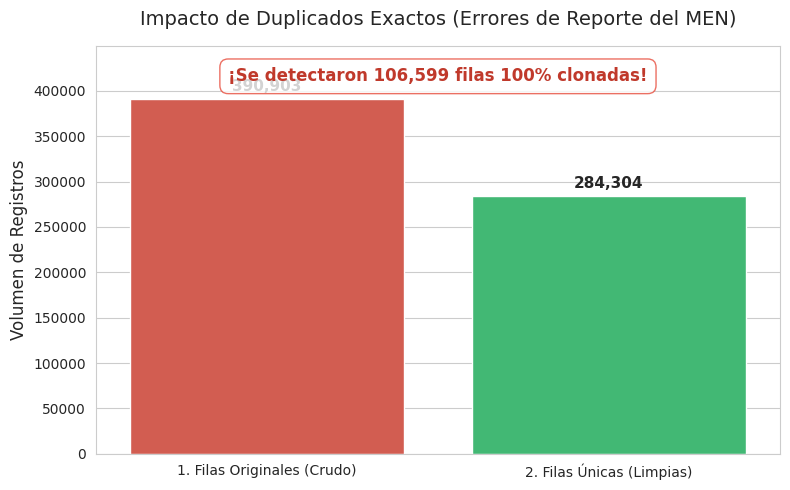

In [25]:
# Calcular dimensiones
total_filas = len(df)
filas_unicas = len(df.drop_duplicates())
duplicados_exactos = total_filas - filas_unicas

# Preparar datos para el gráfico
datos_clones = pd.DataFrame({
    'Estado': ['1. Filas Originales (Crudo)', '2. Filas Únicas (Limpias)'],
    'Cantidad': [total_filas, filas_unicas]
})

# Configurar estilo
plt.figure(figsize=(8, 5))
sns.set_style("whitegrid")

# Crear gráfico de barras
ax = sns.barplot(x='Estado', y='Cantidad', data=datos_clones, palette=['#e74c3c', '#2ecc71'])

# Añadir etiquetas de datos encima de las barras
for p in ax.patches:
    ax.annotate(f'{int(p.get_height()):,}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center',
                xytext=(0, 9),
                textcoords='offset points',
                fontsize=11, fontweight='bold')

plt.title('Impacto de Duplicados Exactos (Errores de Reporte del MEN)', fontsize=14, pad=15)
plt.ylabel('Volumen de Registros', fontsize=12)
plt.xlabel('')
plt.ylim(0, total_filas * 1.15) # Dar espacio arriba para el texto

# Añadir nota explicativa dentro del gráfico
plt.text(0.5, total_filas * 1.05, f'¡Se detectaron {duplicados_exactos:,} filas 100% clonadas!',
            ha='center', color='#c0392b', fontweight='bold', fontsize=12,
            bbox=dict(facecolor='white', alpha=0.8, edgecolor='#e74c3c', boxstyle='round,pad=0.5'))

plt.tight_layout()
plt.show()

/tmp/ipykernel_26120/3234074893.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x='Valores Únicos', y='Entidad / Dimensión', data=df_cardinalidad, palette='viridis')


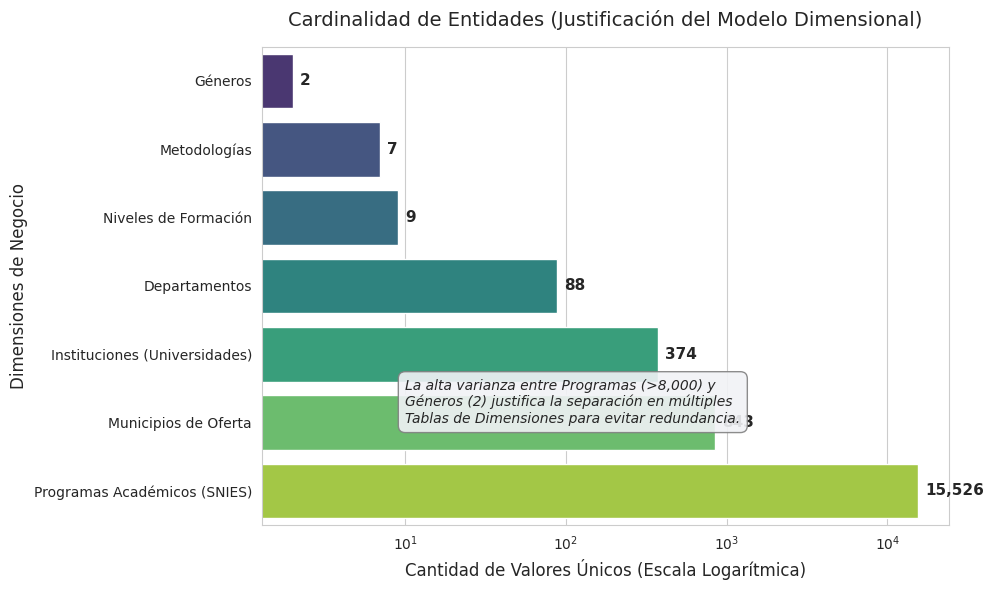

In [27]:
cardinalidad = {
    'Programas Académicos (SNIES)': df['Código SNIES delprograma'].nunique(),
    'Municipios de Oferta': df['Código del Municipio(Programa)'].nunique(),
    'Instituciones (Universidades)': df['Institución de Educación Superior (IES)'].nunique(),
    'Departamentos': df['Departamento de oferta del programa'].nunique(),
    'Niveles de Formación': df['Id_Nivel_Formacion'].nunique(),
    'Metodologías': df['Id_Metodologia'].nunique(),
    'Géneros': df['Id Género'].nunique()
}

# Convertir a DataFrame y ordenar de mayor a menor
df_cardinalidad = pd.DataFrame(list(cardinalidad.items()), columns=['Entidad / Dimensión', 'Valores Únicos'])
df_cardinalidad = df_cardinalidad.sort_values('Valores Únicos', ascending=True)

# Configurar gráfico
plt.figure(figsize=(10, 6))
sns.set_style("whitegrid")

# Gráfico de barras horizontales (ideal para etiquetas largas)
ax = sns.barplot(x='Valores Únicos', y='Entidad / Dimensión', data=df_cardinalidad, palette='viridis')

# Añadir etiquetas de datos a la derecha de las barras
for p in ax.patches:
    ax.annotate(f'{int(p.get_width()):,}',
                (p.get_width(), p.get_y() + p.get_height() / 2.),
                ha='left', va='center',
                xytext=(5, 0),
                textcoords='offset points',
                fontsize=11, fontweight='bold')

# Escala logarítmica en el eje X para que los valores pequeños (Género=2) se vean junto a los gigantes (Programas=10,000)
plt.xscale('log')

plt.title('Cardinalidad de Entidades (Justificación del Modelo Dimensional)', fontsize=14, pad=15)
plt.xlabel('Cantidad de Valores Únicos (Escala Logarítmica)', fontsize=12)
plt.ylabel('Dimensiones de Negocio', fontsize=12)

# Añadir nota explicativa
nota = ("La alta varianza entre Programas (>8,000) y\n"
        "Géneros (2) justifica la separación en múltiples\n"
        "Tablas de Dimensiones para evitar redundancia.")
plt.text(10, 5, nota, fontsize=10, style='italic',
        bbox=dict(facecolor='#f1f2f6', alpha=0.9, edgecolor='gray', boxstyle='round,pad=0.5'))

plt.tight_layout()
plt.show()

In [15]:
# tranformacion temporal
df.columns = df.columns.str.lower()

In [16]:
text_colummns = df.select_dtypes(include=['object', 
                                        'string']).columns

for column in text_colummns:
    df[column] = df[column].str.lower()
    
df.head(100)

,código de la institución,ies padre,institución de educación superior (ies),principal oseccional,id_sector,id_caracter,código del departamento(ies),departamento de domicilio de la ies,código del municipio(ies),municipio dedomicilio de la ies,...,id_nucleo,núcleo básico del conocimiento (nbc),código del departamento(programa),departamento de oferta del programa,código del municipio(programa),municipio de oferta del programa,id género,año,semestre,total matriculados
0,2833,2833,corporacion universitaria remington,principal,2,3,5,antioquia,5001,medellin,...,612,contaduria publica,23,cordoba,23670,san andres de sotavento,2,2015,1,2
1,2833,2833,corporacion universitaria remington,principal,2,3,5,antioquia,5001,medellin,...,612,contaduria publica,23,cordoba,23670,san andres de sotavento,1,2015,1,2
2,2833,2833,corporacion universitaria remington,principal,2,3,5,antioquia,5001,medellin,...,612,contaduria publica,23,cordoba,23672,san antero,2,2015,1,9
3,2833,2833,corporacion universitaria remington,principal,2,3,5,antioquia,5001,medellin,...,612,contaduria publica,23,cordoba,23672,san antero,1,2015,1,1
4,2833,2833,corporacion universitaria remington,principal,2,3,5,antioquia,5001,medellin,...,612,contaduria publica,23,cordoba,23675,san bernardo del viento,2,2015,1,18
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,1101,1101,universidad nacional de colombia,principal,1,4,11,bogota d.c.,11001,bogota d.c.,...,934,biologia microbiologia y afines,11,bogota d.c.,11001,bogota d.c.,2,2015,1,283
96,1101,1101,universidad nacional de colombia,principal,1,4,11,bogota d.c.,11001,bogota d.c.,...,934,biologia microbiologia y afines,11,bogota d.c.,11001,bogota d.c.,1,2015,1,318
97,1101,1101,universidad nacional de colombia,principal,1,4,11,bogota d.c.,11001,bogota d.c.,...,937,matematicas estadistica y afines,11,bogota d.c.,11001,bogota d.c.,2,2015,1,117
98,1101,1101,universidad nacional de colombia,principal,1,4,11,bogota d.c.,11001,bogota d.c.,...,937,matematicas estadistica y afines,11,bogota d.c.,11001,bogota d.c.,1,2015,1,262


In [17]:
df["departamento de domicilio de la ies"].unique()

<StringArray>
[                                               'antioquia',
                                              'bogota d.c.',
                                                    'cauca',
                                                   'narino',
                                                  'bolivar',
                                                  'quindío',
                                                'atlantico',
                                                   'caldas',
                                                'santander',
                                          'valle del cauca',
                                                'risaralda',
                                                    'sucre',
                                                    'huila',
                                                   'boyaca',
                                                   'tolima',
                                                  'cordoba',
          

In [ ]:
df["departamento de oferta del programa"].unique()

In [ ]:
df["id género"].unique() # por si depronto hay valores que no sean 1 y 2